In [ ]:
pip install librosa tensorflow matplotlib

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
import matplotlib.pyplot as plt

In [ ]:
import os
import numpy as np
import librosa
import matplotlib.pyplot as plt
import tensorflow as tf

# Parameters
sample_rate = 22050      # Standard sampling rate for audio
duration = 5             # seconds (adjust if needed)
n_mels = 128             # Number of mel bands
target_frames = 128      # Target number of frames for the spectrogram

# Define your chord labels (folder names)
chords = ['Am', 'Bb', 'Bdim', 'C', 'Dm', 'Em', 'F', 'G']
label_to_index = {label: idx for idx, label in enumerate(chords)}

def load_wav_file(file_path, duration=duration, sr=sample_rate):
    """Load an audio file and pad if it's shorter than the target duration."""
    y, sr = librosa.load(file_path, sr=sr, duration=duration)
    expected_length = sr * duration
    if len(y) < expected_length:
        y = np.pad(y, (0, expected_length - len(y)), mode='constant')
    return y

def wav_to_mel_spec(file_path):
    """Convert a WAV file to a mel spectrogram (in dB) and adjust its time dimension."""
    y = load_wav_file(file_path)
    mel_spec = librosa.feature.melspectrogram(y=y, sr=sample_rate, n_mels=n_mels)
    mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)

    # Adjust the time dimension to target_frames (pad or crop)
    if mel_spec_db.shape[1] < target_frames:
        pad_width = target_frames - mel_spec_db.shape[1]
        mel_spec_db = np.pad(mel_spec_db, ((0, 0), (0, pad_width)), mode='constant')
    else:
        mel_spec_db = mel_spec_db[:, :target_frames]

    # Expand dims to add a channel dimension for CNN input
    mel_spec_db = np.expand_dims(mel_spec_db, axis=-1)
    return mel_spec_db

def load_dataset(data_dir):
    """
    Load dataset from a given directory.
    Expected structure:
      data_dir/
         Am/
            file1.wav, file2.wav, ...
         Bb/
            file1.wav, ...
         etc.
    Returns: tuple of (X, y)
    """
    X = []
    y = []
    print(f"Loading data from: {data_dir}")
    for chord in chords:
        folder = os.path.join(data_dir, chord)
        print(f"Checking folder: {folder}")
        if not os.path.exists(folder):
            print(f"Folder {folder} not found.")
            continue
        for file in os.listdir(folder):
            if file.endswith(".wav"):
                file_path = os.path.join(folder, file)
                print(f"Found file: {file_path}")
                spec = wav_to_mel_spec(file_path)
                X.append(spec)
                y.append(label_to_index[chord])
    X = np.array(X)
    y = np.array(y)
    if len(X) > 0:
        y = tf.keras.utils.to_categorical(y, num_classes=len(chords))
    return X, y

# Set your dataset paths
test_dir = "/content/drive/MyDrive/archive/Test"
train_dir = "/content/drive/MyDrive/archive/Training"


# Load the training and testing datasets
X_train, y_train = load_dataset(train_dir)
X_test, y_test = load_dataset(test_dir)

print("Training set shape:", X_train.shape)  # Expected: (num_train_samples, 128, 128, 1)
print("Testing set shape:", X_test.shape)


Loading data from: /content/drive/MyDrive/archive/Training
Checking folder: /content/drive/MyDrive/archive/Training/Am
Found file: /content/drive/MyDrive/archive/Training/Am/Am_AcusticPlug15_2.wav
Found file: /content/drive/MyDrive/archive/Training/Am/Am_AcusticPlug15_1.wav
Found file: /content/drive/MyDrive/archive/Training/Am/Am_AcusticPlug15_3.wav
Found file: /content/drive/MyDrive/archive/Training/Am/Am_AcusticPlug18_1.wav
Found file: /content/drive/MyDrive/archive/Training/Am/Am_AcusticPlug26_3.wav
Found file: /content/drive/MyDrive/archive/Training/Am/Am_AcusticPlug18_2.wav
Found file: /content/drive/MyDrive/archive/Training/Am/Am_AcusticPlug21_2.wav
Found file: /content/drive/MyDrive/archive/Training/Am/Am_AcusticPlug24_4.wav
Found file: /content/drive/MyDrive/archive/Training/Am/Am_AcusticPlug23_4.wav
Found file: /content/drive/MyDrive/archive/Training/Am/Am_AcusticPlug20_2.wav
Found file: /content/drive/MyDrive/archive/Training/Am/Am_AcusticPlug20_4.wav
Found file: /content/dr

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 126, 126, 32)        │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 63, 63, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 61, 61, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 57600)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │       7,372,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 8)                   │           1,032 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 7,392,776 (28.20 MB)

 Trainable params: 7,392,776 (28.20 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 39s 828ms/step - accuracy: 0.1558 - loss: 44.8907 - val_accuracy: 0.6438 - val_loss: 1.2292
Epoch 2/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 38s 763ms/step - accuracy: 0.7921 - loss: 0.6550 - val_accuracy: 0.9094 - val_loss: 0.2919
Epoch 3/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 40s 741ms/step - accuracy: 0.9350 - loss: 0.2132 - val_accuracy: 0.9312 - val_loss: 0.3056
Epoch 4/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 43s 784ms/step - accuracy: 0.9503 - loss: 0.1266 - val_accuracy: 0.9469 - val_loss: 0.2829
Epoch 5/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 40s 749ms/step - accuracy: 0.9629 - loss: 0.1014 - val_accuracy: 0.9594 - val_loss: 0.2288
Epoch 6/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 47s 878ms/step - accuracy: 0.9736 - loss: 0.0836 - val_accuracy: 0.9688 - val_loss: 0.2132
Epoch 7/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 35s 777ms/step - accuracy: 0.9727 - loss: 0.0702 - val_accuracy: 0.9625 - val_loss: 0.2261
Epoch 8/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 41s 780ms/step - accuracy: 0.9780 - loss: 0.0559 - val_acc

Model saved successfully!
10/10 - 3s - 295ms/step - accuracy: 0.9594 - loss: 0.2488
Test accuracy: 0.9593750238418579


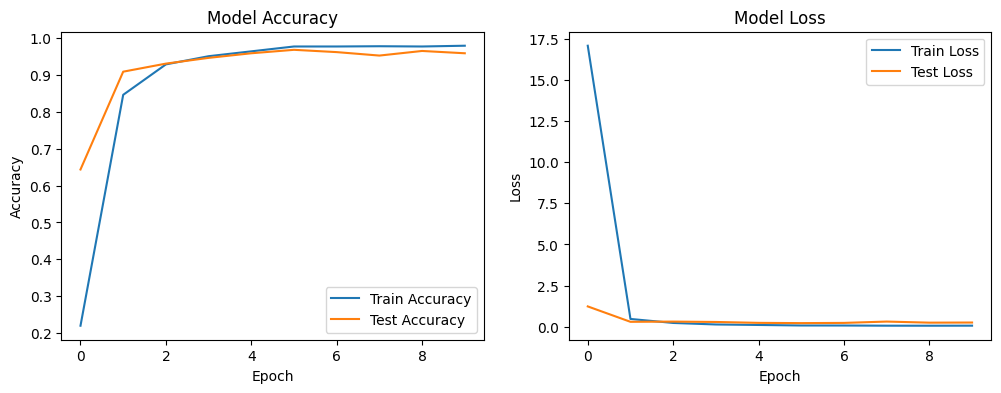

In [ ]:

if X_train.shape[0] == 0 or X_test.shape[0] == 0:
    raise ValueError("No data found. Please verify your dataset path and folder structure.")

# Build the CNN model
num_classes = len(chords)
model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(n_mels, target_frames, 1)),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])
model.summary()

# Train the model
epochs = 10
batch_size = 32

history = model.fit(X_train, y_train,
                    validation_data=(X_test, y_test),
                    batch_size=batch_size,
                    epochs=epochs)

# Save the model
model.save("guitar_chord_detection_model.h5")
print("Model saved successfully!")

# Evaluate the model
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=2)
print("Test accuracy:", test_acc)

# Plot the training history
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Test Accuracy')
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Test Loss')
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [ ]:
def predict_chord(file_path, model, label_map):
    """Predict the chord class of a single WAV file."""
    if not os.path.exists(file_path):
        print(f"File not found: {file_path}")
        return

    # Convert to mel spectrogram
    spec = wav_to_mel_spec(file_path)
    spec = np.expand_dims(spec, axis=0)  # Add batch dimension

    # Predict
    predictions = model.predict(spec)
    predicted_index = np.argmax(predictions)
    predicted_label = [label for label, index in label_map.items() if index == predicted_index][0]

    print(f"Predicted chord: {predicted_label}")
    return predicted_label


Enter the full path to your WAV file: /content/How To Play The Dm Chord On Guitar - Guvna Guitars - Guvna Guitars-[AudioTrimmer.com].mp3
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
Predicted chord: Dm


'Dm'